--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Missing Values Count ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             

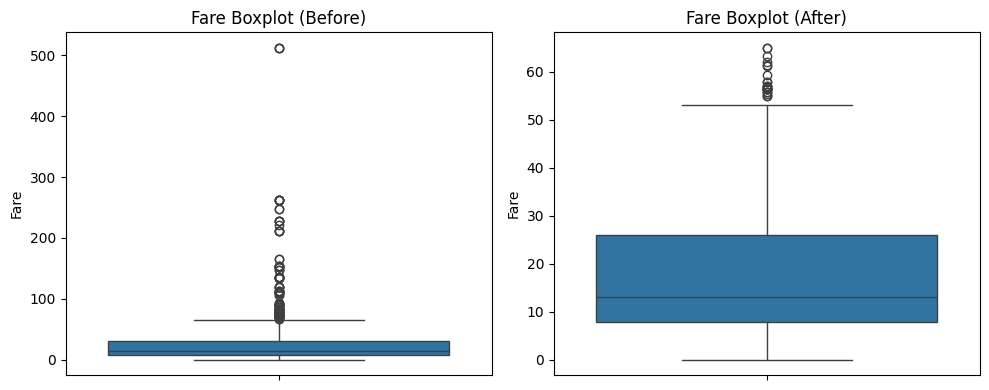


--- Cleaned and Processed Dataset Preview ---
   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked_Q  \
0         0       3    1 -0.528321  0.625606 -0.433718 -0.779117           0   
2         1       3    0 -0.215182 -0.486423 -0.433718 -0.729373           0   
3         1       1    0  0.489381  0.625606 -0.433718  2.599828           0   
4         0       3    1  0.489381 -0.486423 -0.433718 -0.720161           0   
5         0       3    1 -0.058613 -0.486423 -0.433718 -0.690071           1   

   Embarked_S  
0           1  
2           1  
3           1  
4           1  
5           0  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ----------------------------------------------------
# 1. Import Dataset & Initial Exploration
# ----------------------------------------------------
# Loading the classic Titanic dataset from an online source
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# ----------------------------------------------------
# 2. Handle Missing Values
# ----------------------------------------------------
# Numerical: Fill missing 'Age' with the median (robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Categorical: Fill missing 'Embarked' with the most frequent value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' because it has too many missing values (>70%) to safely impute
df.drop(columns=['Cabin'], inplace=True)

# ----------------------------------------------------
# 3. Convert Categorical Features to Numerical
# ----------------------------------------------------
# Label Encoding for binary/ordinal-like features ('Sex')
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# One-Hot Encoding for nominal features ('Embarked')
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

# Drop irrelevant text columns for basic ML modeling
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# ----------------------------------------------------
# 4. Outlier Detection and Removal (IQR Method)
# ----------------------------------------------------
# Visualize 'Fare' before removing outliers
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='Fare')
plt.title('Fare Boxplot (Before)')

# Calculate IQR for 'Fare'
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

# Visualize 'Fare' after removing outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='Fare')
plt.title('Fare Boxplot (After)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 5. Normalize / Standardize Numerical Features
# ----------------------------------------------------
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\n--- Cleaned and Processed Dataset Preview ---")
print(df.head())